In [ ]:

#Preparación de la estructura (Data Splitting)
import os
import shutil
import random

# montar el entorno de drive - esto es para que me encuentren los ficheros,
from google.colab import drive
drive.mount('/content/drive')

# incorporar el nombre del proyecto
ruta_proyecto = '/content/drive/MyDrive/'
os.chdir(ruta_proyecto)




Mounted at /content/drive


In [ ]:
#Preparación de la estructura (Data Splitting)
def organizar_para_yolo(input_dir, output_dir, split=0.8):
    # Creamos carpetas raíz
    for s in ['train', 'val']:
        os.makedirs(os.path.join(output_dir, 'images', s), exist_ok=True)
        # Nota: YOLO para detección de objetos usa carpetas 'labels',
        # pero como estamos haciendo Clasificación inicial, se usa estructura por carpetas.

    clases = [d for d in os.listdir(input_dir) if os.path.isdir(os.path.join(input_dir, d))]

    for clase in clases:
        ruta_clase = os.path.join(input_dir, clase)
        imagenes = os.listdir(ruta_clase)
        random.shuffle(imagenes)

        limite = int(len(imagenes) * split)
        train_imgs = imagenes[:limite]
        val_imgs = imagenes[limite:]

        # Copiar archivos
        for img in train_imgs:
            os.makedirs(os.path.join(output_dir, 'train', clase), exist_ok=True)
            shutil.copy(os.path.join(ruta_clase, img), os.path.join(output_dir, 'train', clase, img))

        for img in val_imgs:
            os.makedirs(os.path.join(output_dir, 'val', clase), exist_ok=True)
            shutil.copy(os.path.join(ruta_clase, img), os.path.join(output_dir, 'val', clase, img))

    print(f"✅ Dataset organizado en {output_dir}")

# Ejecución
organizar_para_yolo("./fridge_preprocessed", "./yolo_dataset")

In [ ]:
#Entrenamiento del Modelo Local
# Instala la librería necesaria para usar YOLOv8
!pip install ultralytics
from ultralytics import YOLO

# 1. Cargar un modelo base (nano es el más rápido para pruebas locales)
# Usamos 'yolov8n-cls.pt' porque tu dataset está organizado por carpetas (clasificación)
model = YOLO('yolov8n-cls.pt')

# 2. Entrenar el modelo
results = model.train(
    data="./yolo_dataset",
    epochs=5,             # Número de pasadas por el dataset
    imgsz=640,             # Tamaño de imagen (el mismo que tu preprocesado)
    batch=16,              # Ajustar según la memoria de tu GPU/CPU
    name='modelo_frigorifico_v1'
)

print("🚀 Entrenamiento finalizado. Modelo guardado en: runs/classify/modelo_frigorifico_v1/weights/best.pt")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_dataset, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None,

In [ ]:
#métricas del modelo
# 1. Ejecutar validación sobre el conjunto de test/val
metrics = model.val()

# 2. Extraer parámetros de Precisión
print("===== MÉTRICAS DE PRECISIÓN =====")
print(f"Precisión Top-1 (Exactitud): {metrics.top1 * 100:.2f}%")
print(f"Precisión Top-5: {metrics.top5 * 100:.2f}%")

# 3. Extraer parámetros de Inferencia (Latencia)
# Los tiempos están en milisegundos (ms) por imagen
tiempos = metrics.speed
print("\n===== MÉTRICAS DE LATENCIA (INFERENCIA) =====")
print(f"Pre-procesado: {tiempos['preprocess']:.2f} ms")
print(f"Inferencia (IA): {tiempos['inference']:.2f} ms")
print(f"Post-procesado: {tiempos['postprocess']:.2f} ms")
print(f"TIEMPO TOTAL: {sum(tiempos.values()):.2f} ms por imagen")


Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,470,748 parameters, 0 gradients, 3.3 GFLOPs
train: /content/drive/MyDrive/yolo_dataset/train... found 5938 images in 28 classes ✅ 
val: /content/drive/MyDrive/yolo_dataset/val... found 1498 images in 28 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 34.9±7.9 MB/s, size: 85.1 KB)
val: Scanning /content/drive/MyDrive/yolo_dataset/val... 1498 images, 0 corrupt: 100% ━━━━━━━━━━━━ 1498/1498 261.8Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 94/94 3.3it/s 28.6s
                   all      0.688      0.963
Speed: 0.8ms preprocess, 2.4ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/drive/MyDrive/runs/classify/val2
===== MÉTRICAS DE PRECISIÓN =====
Precisión Top-1 (Exactitud): 68.76%
Precisión Top-5: 96.26%

===== MÉTRICAS DE LATENCIA (INFERENCIA) =====
Pre-procesado: 0.82 ms
Inferenc

In [ ]:
#PRUEBAS DE DETECCIÓN
#1. cargar el modelo
from ultralytics import YOLO

# Cargamos el modelo que acabas de entrenar
model_path = '/content/drive/MyDrive/runs/classify/modelo_frigorifico_v13/weights/best.pt'
model = YOLO(model_path)

print("✅ Modelo cargado y listo para identificar alimentos.")


✅ Modelo cargado y listo para identificar alimentos.



image 1/1 /content/drive/MyDrive/__Imagenes_prueba/Frigo_prueba9.jpg: 640x640 __Imagenes_prueba 0.62, Beer 0.18, Wine 0.09, Turkey 0.07, Juice 0.01, 4.2ms
Speed: 17.8ms preprocess, 4.2ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 640)
⚠️ Ignorando clase de prueba, saltando al siguiente mejor...
🎯 Ingrediente detectado: Beer (18.13%)

Top 5 posibilidades:
- __Imagenes_prueba: 0.6236
- Beer: 0.1813
- Wine: 0.0927
- Turkey: 0.0674
- Juice: 0.0127


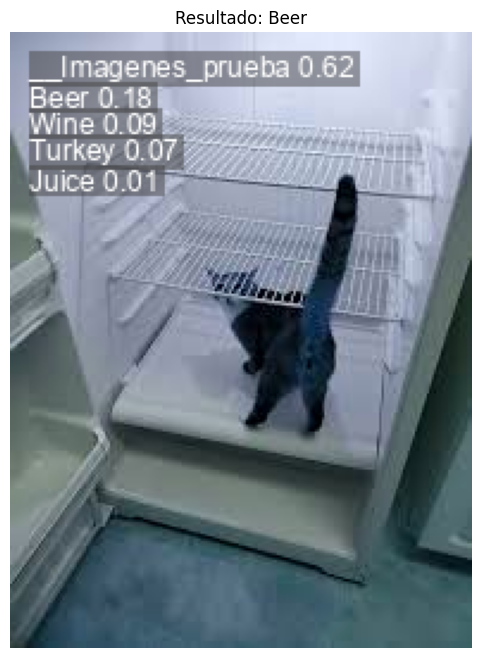

In [ ]:
#PRUEBAS DE DETECCIÓN
#2. Uso del modelo para detectar una imagen
import matplotlib.pyplot as plt

# 2. Definir la ruta de tu imagen en Drive
img_path = '/content/drive/MyDrive/__Imagenes_prueba/Frigo_prueba9.jpg'

# Verificar si el archivo existe antes de procesar
if os.path.exists(img_path):
    # 3. Realizar la predicción
    results = model.predict(source=img_path, imgsz=640)

    for result in results:
      top5_indices = result.probs.top5
      nombre_clase = result.names[top5_indices[0]] # El ganador

      # TRUCO: Si el ganador es la carpeta de errores, cogemos el segundo
      if nombre_clase == "__Imagenes_prueba":
        print("⚠️ Ignorando clase de prueba, saltando al siguiente mejor...")
        nombre_clase = result.names[top5_indices[1]]
        confianza = result.probs.data[top5_indices[1]].item()
      else:
        confianza = result.probs.top1conf.item()

      print(f"🎯 Ingrediente detectado: {nombre_clase} ({confianza:.2%})")

      # 4. CORRECCIÓN: Mostrar el Top 5 usando .data
      print("\nTop 5 posibilidades:")
      top5_indices = result.probs.top5
      confidencias_todas = result.probs.data # Accedemos al tensor de datos

      for idx in top5_indices:
            # Extraemos el valor del tensor usando .item()
            valor_conf = confidencias_todas[idx].item()
            print(f"- {result.names[idx]}: {valor_conf:.4f}")

      # 5. Visualizar
      res_plotted = result.plot()
      plt.figure(figsize=(8, 8))
      plt.imshow(res_plotted)
      plt.title(f"Resultado: {nombre_clase}")
      plt.axis('off')
      plt.show()
else:
    print(f"❌ No se encontró la imagen en {img_path}")



In [ ]:
#guardar copia de seguridad del experimento
import shutil

# Comprimimos toda la carpeta de resultados de la v13
shutil.make_archive('/content/drive/MyDrive/fridge_copia_seguridad/copia_202603041200_v13', 'zip', '/content/drive/MyDrive/runs/classify/modelo_frigorifico_v13')

print("✅ Todo el experimento (pesos, gráficas y configuración) se ha guardado en un ZIP.")


✅ Todo el experimento (pesos, gráficas y configuración) se ha guardado en un ZIP.
